# MVP – Sprint 3: Machine Learning
## Previsão de Demanda por Categoria de Produto – Bagaggio

**Aluna:** Diana Serrano  
**Curso:** Pós-Graduação em Ciência de Dados – PUC-Rio  
**Data:** Junho/2025

---

## 1. Problema de Negócio

### Contexto

A **Bagaggio** é uma varejista especializada em malas, mochilas, bolsas e acessórios de viagem, com operação em lojas físicas próprias, franquias e e-commerce. Com um mix amplo de produtos e forte variação sazonal nas vendas, o planejamento de estoque é um desafio crítico para o negócio.

### Sazonalidade do negócio

A Bagaggio possui épocas bem definidas de alta demanda, cada uma com foco em categorias distintas:

| Época | Período | Categorias em destaque |
|-------|---------|------------------------|
| Volta às Aulas | Janeiro – Fevereiro | Mochilas, Lancheiras, Estojos (Infantil/Juvenil) |
| Dia das Mães | Maio | Bolsas, Necessaire |
| Dia dos Pais | Agosto | Executivo, Pastas, Malas |
| Black Friday | Outubro–Novembro | Malas (Bordo e Despacho) |
| Natal | Dezembro | Mix geral, produtos acessíveis |

### Processo atual de planejamento de compras

Atualmente, o planejamento de compras da Bagaggio é feito com base no **histórico de vendas do período anterior acrescido de um percentual fixo de crescimento estimado (5% ao ano)**. Esse método, embora razoável como ponto de partida, apresenta limitações importantes:

- **Ignora sazonalidade por categoria:** uma mochila infantil e uma mala de despacho têm picos completamente diferentes, mas recebem o mesmo fator de crescimento
- **Ignora diferenças entre canais:** o e-commerce tem comportamento distinto das lojas físicas, especialmente na Black Friday
- **Não captura padrões não-lineares:** crescimento de 5% não reflete quedas abruptas ou picos extraordinários
- **Decisão manual e subjetiva:** depende da experiência individual de cada comprador

### Objetivo

> **Construir um modelo de Machine Learning capaz de prever a quantidade de itens vendidos por categoria de produto e canal de venda, superando o método atual de previsão baseado em crescimento fixo de 5% ao ano.**

O modelo baseline (lógica atual da empresa) será implementado e comparado diretamente com os algoritmos de ML, respondendo objetivamente à pergunta: **o Machine Learning é melhor do que o que já fazemos?**

### Tipo de problema

Este é um problema de **regressão supervisionada**: a variável-alvo (`QTD`) é contínua e queremos prever seu valor futuro com base em features históricas e calendáricas.

---

## 2. Configuração do Ambiente

In [32]:
# Instalação de dependências (caso necessário)
# !pip install scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
CORES_BAGAGGIO = ['#1B3A6B', '#C8A951', '#8B1A1A', '#4A7FC1', '#6B6B6B']

print('✅ Bibliotecas carregadas com sucesso!')

✅ Bibliotecas carregadas com sucesso!


## 3. Carga dos Dados

In [33]:


URL_DATASET = 'https://raw.githubusercontent.com/DianaSerrano1/MVP-MachineLearning/main/base_ML.csv'
df_raw = pd.read_csv(URL_DATASET, sep=';', encoding='utf-8')

# Limpeza de espaços em branco ( rtrim  ~ strip)
df_raw.columns = df_raw.columns.str.strip()
for col in ['NIVEL1', 'NIVEL2', 'NIVEL3', 'CANAL']:
    df_raw[col] = df_raw[col].str.strip()

# Conversão de tipos
df_raw['DATA_EMISSAO'] = pd.to_datetime(df_raw['DATA_EMISSAO'], format='%Y%m%d')
df_raw['VALOR'] = df_raw['VALOR'].str.replace(',', '.').astype(float)
df_raw['QTD'] = pd.to_numeric(df_raw['QTD'], errors='coerce')

print(f'Shape original: {df_raw.shape}')
print(f'Período: {df_raw["DATA_EMISSAO"].min().date()} até {df_raw["DATA_EMISSAO"].max().date()}')
print(f'\nPrimeiras linhas:')
df_raw.head()

Shape original: (84921, 7)
Período: 2024-06-01 até 2026-06-01

Primeiras linhas:


,DATA_EMISSAO,NIVEL1,NIVEL2,NIVEL3,QTD,VALOR,CANAL
0,2025-09-17,ESCOLARES,MOCHILAS,JUVENIL,32.0,8723.77,A
1,2025-08-18,MALAS,DESPACHO,UNICO,169.0,95507.43,P
2,2025-12-15,COTIDIANO,BOLSAS,UNICO,267.0,32206.97,P
3,2026-01-12,ESCOLARES,MOCHILAS,PRE-ESCOLAR,138.0,25190.55,P
4,2025-09-16,MOCHILAS,CASUAL,FEMININO,13.0,2118.38,A


## 4. Análise Exploratória dos Dados (EDA)

Antes de modelar, precisamos entender a estrutura dos dados, identificar anomalias e validar hipóteses de negócio.

In [34]:
# 4.1 Visão geral da estrutura
print('=== INFORMAÇÕES GERAIS ===')
print(df_raw.info())
print('\n=== VALORES NULOS ===')
print(df_raw.isnull().sum())
print('\n=== ESTATÍSTICAS DESCRITIVAS ===')
df_raw[['QTD', 'VALOR']].describe()

=== INFORMAÇÕES GERAIS ===
<class 'pandas.DataFrame'>
RangeIndex: 84921 entries, 0 to 84920
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   DATA_EMISSAO  84921 non-null  datetime64[us]
 1   NIVEL1        84921 non-null  str           
 2   NIVEL2        84921 non-null  str           
 3   NIVEL3        84921 non-null  str           
 4   QTD           84920 non-null  float64       
 5   VALOR         84921 non-null  float64       
 6   CANAL         84921 non-null  str           
dtypes: datetime64[us](1), float64(2), str(4)
memory usage: 6.6 MB
None

=== VALORES NULOS ===
DATA_EMISSAO    0
NIVEL1          0
NIVEL2          0
NIVEL3          0
QTD             1
VALOR           0
CANAL           0
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS ===


,QTD,VALOR
count,84920.000000,8.492100e+04
mean,59.251390,1.178415e+04
std,109.891089,3.672427e+04
min,-74.000000,-1.340849e+05
25%,5.000000,4.917000e+02
50%,20.000000,2.262220e+03
75%,64.000000,5.998240e+03
max,3986.000000,2.269490e+06


O dataset apresentou apenas 1 valor nulo em QTD e 198 registros com quantidade negativa, representando devoluções e cancelamentos (< 0,3% da base). Ambos serão tratados na etapa de limpeza, na seção 5

In [35]:
# 4.2 Distribuição por Canal
print('=== DISTRIBUIÇÃO POR CANAL ===')
canal_desc = {
    'P': 'Loja Própria',
    'A': 'Loja Própria (A)',
    'F': 'Franquia',
    'E': 'E-commerce',
    'I': 'Interno (descartado)'
}
canal_counts = df_raw['CANAL'].value_counts().reset_index()
canal_counts.columns = ['CANAL', 'Registros']
canal_counts['Descrição'] = canal_counts['CANAL'].map(canal_desc)
print(canal_counts.to_string(index=False))

=== DISTRIBUIÇÃO POR CANAL ===
CANAL  Registros            Descrição
    P      26849         Loja Própria
    A      26826     Loja Própria (A)
    E      18984           E-commerce
    F      12218             Franquia
    I         44 Interno (descartado)


In [36]:
# 4.3 Análise dos níveis de categoria
print('=== NIVEL1 (Categorias principais) ===')
print(df_raw['NIVEL1'].value_counts())
print(f'\n=== NIVEL2 (Subcategorias) — {df_raw["NIVEL2"].nunique()} únicos ===')
print(df_raw['NIVEL2'].value_counts())
print(f'=== NIVEL3 — {df_raw["NIVEL3"].nunique()} únicos ===')
print(df_raw['NIVEL3'].value_counts())

=== NIVEL1 (Categorias principais) ===
NIVEL1
COTIDIANO    26825
ESCOLARES    20312
VIAGEM       18097
MOCHILAS      9369
MALAS         8058
OUTROS        2260
Name: count, dtype: int64

=== NIVEL2 (Subcategorias) — 25 únicos ===
NIVEL2
TERMICOS            8409
MOCHILAS            7095
LANCHEIRAS          6682
CARTEIRAS           5119
EXECUTIVO           4886
NECESSAIRE          4727
CASUAL              4483
ESTOJOS             4333
PASTAS              4189
BORDO               2739
DESPACHO            2724
BOLSAS              2572
BOLSAS DE VIAGEM    2540
CAPAS DE MALA       2484
ETIQUETAS           2404
DIVERSOS            2287
ALMOFADAS           2278
OUTROS              2260
ORGANIZADORES       2257
CADEADOS            2217
FRASQUEIRA          2140
GUARDA CHUVA        2077
PORTA DOLAR         2030
CINTOS              1928
KIT                   61
Name: count, dtype: int64
=== NIVEL3 — 9 únicos ===
NIVEL3
UNICO          32738
MASCULINO      12238
FEMININO       11166
INFANTIL        

In [37]:
print(f'=== NIVEL3 — {df_raw["NIVEL3"].nunique()} únicos ===')
print(df_raw['NIVEL3'].value_counts())

=== NIVEL3 — 9 únicos ===
NIVEL3
UNICO          32738
MASCULINO      12238
FEMININO       11166
INFANTIL        9358
JUVENIL         6395
PRE-ESCOLAR     4553
OUTROS          3957
GARRAFAS        2411
LANCHEIRAS      2105
Name: count, dtype: int64


In [38]:
# Linhas por NIVEL1 (o que apareceu antes)
print('=== REGISTROS (linhas) por NIVEL1 ===')
print(df_raw.groupby('NIVEL1')['QTD'].count().sort_values(ascending=False))

print('\n=== QUANTIDADE VENDIDA por NIVEL1 ===')
print(df_raw.groupby('NIVEL1')['QTD'].sum().sort_values(ascending=False))

=== REGISTROS (linhas) por NIVEL1 ===
NIVEL1
COTIDIANO    26825
ESCOLARES    20311
VIAGEM       18097
MOCHILAS      9369
MALAS         8058
OUTROS        2260
Name: QTD, dtype: int64

=== QUANTIDADE VENDIDA por NIVEL1 ===
NIVEL1
MALAS        1351247.0
COTIDIANO    1101106.0
VIAGEM       1035963.0
ESCOLARES     864624.0
MOCHILAS      637084.0
OUTROS         41604.0
Name: QTD, dtype: float64


A análise por NIVEL1 revela uma inversão importante: em número de registros, COTIDIANO lidera (26.825 linhas) por ter mais subcategorias, gerando mais combinações de data × categoria × canal. Porém, em volume real de itens vendidos, MALAS é a categoria campeã com 1.351.247 unidades, seguida de COTIDIANO (1.101.106) e VIAGEM (1.035.963). Essa distinção reforça que número de linhas não representa relevância de negócio — e justifica por que a previsão de demanda de MALAS é estratégica para o planejamento de compras da Bagaggio

Decisão: Usar NIVEL2 como granularidade principal
Isso nos dá 25 categorias distintas para modelagem


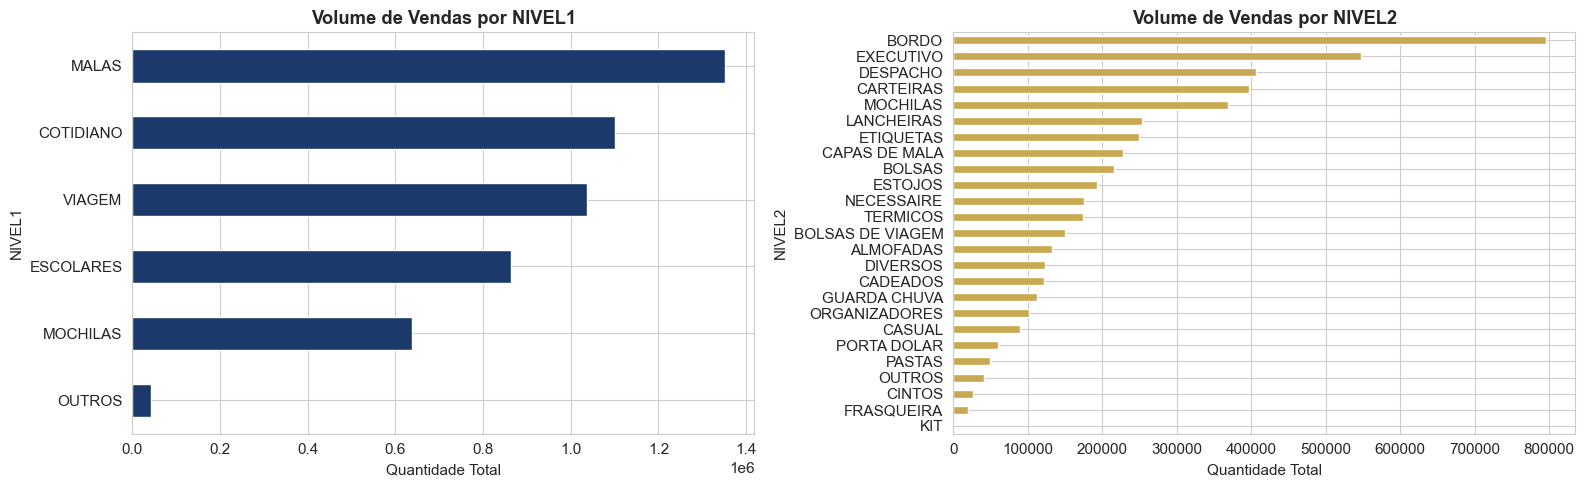

In [39]:
# 4.4 Decisão de agrupamento
# NIVEL1: apenas 6 valores — genérico demais para o modelo
# NIVEL2: 25 valores — Granuaridade ideal. Distingue padrões de demanda
#   entre categorias como BORDO, DESPACHO, MOCHILAS, EXECUTIVO, TERMICOS, etc.
#   Volume real por subcategoria é visível no gráfico abaixo.
# NIVEL3: apenas 9 valores genéricos (UNICO, JUVENIL, FEMININO...) — pouco informativo

# Decisão: usar NIVEL2 como variável de categoria principal
# Justificativa: oferece granularidade suficiente para distinguir padrões de demanda
# NIVEL1 será mantido como contexto adicional no modelo.

print('Decisão: Usar NIVEL2 como granularidade principal')
print(f'Isso nos dá {df_raw["NIVEL2"].nunique()} categorias distintas para modelagem')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# NIVEL1
n1 = df_raw.groupby('NIVEL1')['QTD'].sum().sort_values(ascending=True)
n1.plot(kind='barh', ax=axes[0], color=CORES_BAGAGGIO[0])
axes[0].set_title('Volume de Vendas por NIVEL1', fontweight='bold')
axes[0].set_xlabel('Quantidade Total')

# NIVEL2
n2 = df_raw.groupby('NIVEL2')['QTD'].sum().sort_values(ascending=True)
n2.plot(kind='barh', ax=axes[1], color=CORES_BAGAGGIO[1])
axes[1].set_title('Volume de Vendas por NIVEL2', fontweight='bold')
axes[1].set_xlabel('Quantidade Total')

plt.tight_layout()
plt.show()

In [40]:
print(df_raw.groupby(['NIVEL1','NIVEL2'])['QTD'].sum().sort_values(ascending=False).to_string())

NIVEL1     NIVEL2          
MALAS      BORDO               795394.0
MOCHILAS   EXECUTIVO           547134.0
MALAS      DESPACHO            405970.0
COTIDIANO  CARTEIRAS           396736.0
ESCOLARES  MOCHILAS            369033.0
           LANCHEIRAS          253260.0
VIAGEM     ETIQUETAS           249889.0
           CAPAS DE MALA       228426.0
COTIDIANO  BOLSAS              215269.0
ESCOLARES  ESTOJOS             193291.0
COTIDIANO  NECESSAIRE          175756.0
MALAS      BOLSAS DE VIAGEM    149825.0
VIAGEM     ALMOFADAS           132167.0
COTIDIANO  TERMICOS            124827.0
VIAGEM     DIVERSOS            123582.0
           CADEADOS            121529.0
COTIDIANO  GUARDA CHUVA        112993.0
VIAGEM     ORGANIZADORES       101110.0
MOCHILAS   CASUAL               89950.0
VIAGEM     PORTA DOLAR          59824.0
COTIDIANO  PASTAS               49070.0
ESCOLARES  TERMICOS             49036.0
OUTROS     OUTROS               41604.0
COTIDIANO  CINTOS               26455.0
VIAGEM     F

In [41]:
# Verificar NIVEL2 que aparecem em mais de um NIVEL1
duplicados = df_raw.groupby('NIVEL2')['NIVEL1'].nunique()
print('NIVEL2 com mais de um NIVEL1:')
print(duplicados[duplicados > 1])

NIVEL2 com mais de um NIVEL1:
NIVEL2
KIT         2
TERMICOS    2
Name: NIVEL1, dtype: int64


A análise da combinação NIVEL1 + NIVEL2 revelou que o NIVEL2 isolado 
pode ser ambíguo. Duas subcategorias aparecem em mais de um NIVEL1:

Um TERMICO de uso cotidiano tem padrão de demanda completamente diferente 
de um TERMICO escolar — este tem pico em janeiro/fevereiro (Volta às Aulas), 
enquanto aquele tem demanda mais estável ao longo do ano.

**Decisão revisada:** vou mudar a granularidade principal do modelo passando a ser a 
**chave combinada NIVEL1 + NIVEL2** (ex: "ESCOLARES | TERMICOS"), 
eliminando a ambiguidade e garantindo que cada categoria tenha 
um padrão de demanda único e bem definido.

Isso resulta em `27` categorias únicas

In [42]:
# Criando chave combinada NIVEL1 + NIVEL2
# Resolve a ambiguidade de categorias como TERMICOS e KIT
# que aparecem em mais de um NIVEL1 com padrões de demanda distintos

df_raw['CATEGORIA'] = df_raw['NIVEL1'] + ' | ' + df_raw['NIVEL2']

print(f'Categorias únicas com chave combinada: {df_raw["CATEGORIA"].nunique()}')
print('\nTodas as categorias:')
print(df_raw['CATEGORIA'].value_counts().to_string())

Categorias únicas com chave combinada: 27

Todas as categorias:
CATEGORIA
ESCOLARES | MOCHILAS        7095
ESCOLARES | LANCHEIRAS      6682
COTIDIANO | TERMICOS        6213
COTIDIANO | CARTEIRAS       5119
MOCHILAS | EXECUTIVO        4886
COTIDIANO | NECESSAIRE      4727
MOCHILAS | CASUAL           4483
ESCOLARES | ESTOJOS         4333
COTIDIANO | PASTAS          4189
MALAS | BORDO               2739
MALAS | DESPACHO            2724
COTIDIANO | BOLSAS          2572
MALAS | BOLSAS DE VIAGEM    2540
VIAGEM | CAPAS DE MALA      2484
VIAGEM | ETIQUETAS          2404
VIAGEM | DIVERSOS           2287
VIAGEM | ALMOFADAS          2278
OUTROS | OUTROS             2260
VIAGEM | ORGANIZADORES      2257
VIAGEM | CADEADOS           2217
ESCOLARES | TERMICOS        2196
VIAGEM | FRASQUEIRA         2140
COTIDIANO | GUARDA CHUVA    2077
VIAGEM | PORTA DOLAR        2030
COTIDIANO | CINTOS          1928
MALAS | KIT                   55
ESCOLARES | KIT                6


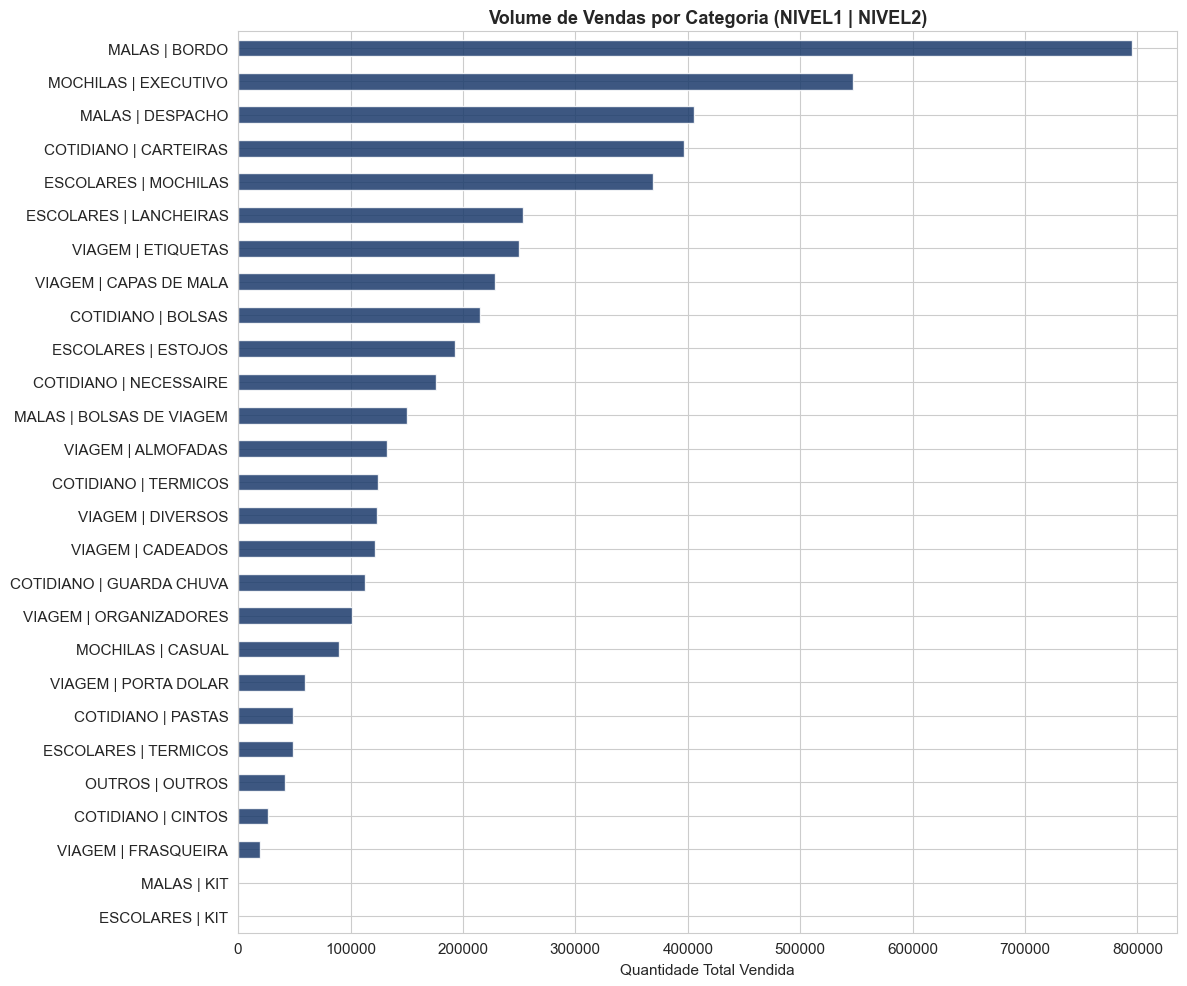

In [43]:
# Volume de vendas por CATEGORIA (chave combinada NIVEL1 + NIVEL2)
fig, ax = plt.subplots(figsize=(12, 10))

cat_volume = df_raw.groupby('CATEGORIA')['QTD'].sum().sort_values(ascending=True)
cat_volume.plot(kind='barh', ax=ax, color=CORES_BAGAGGIO[0], alpha=0.85)

ax.set_title('Volume de Vendas por Categoria (NIVEL1 | NIVEL2)', fontweight='bold', fontsize=13)
ax.set_xlabel('Quantidade Total Vendida')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Com a chave combinada, o gráfico revela a hierarquia real de demanda da Bagaggio. MALAS | BORDO lidera com folga, confirmando que as malas de mão são o carro-chefe do negócio. MOCHILAS | EXECUTIVO aparece em 2º lugar, revelando a força do segmento corporativo. As categorias com volume residual (MALAS | KIT, ESCOLARES | KIT, COTIDIANO | CINTOS) serão avaliadas para possível descarte na etapa de limpeza.

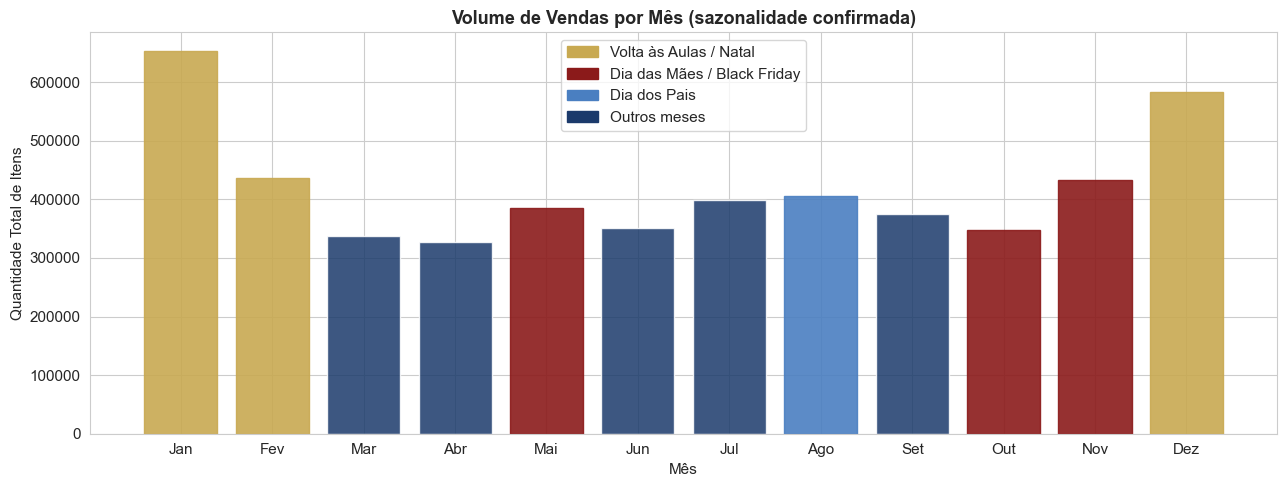

In [44]:
# 4.5 Sazonalidade mensal — validando o conhecimento de negócio
df_raw['MES'] = df_raw['DATA_EMISSAO'].dt.month
df_raw['ANO'] = df_raw['DATA_EMISSAO'].dt.year

vendas_mes = df_raw.groupby('MES')['QTD'].sum().reset_index()
nomes_meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
vendas_mes['MES_NOME'] = vendas_mes['MES'].apply(lambda x: nomes_meses[x-1])

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(vendas_mes['MES_NOME'], vendas_mes['QTD'], color=CORES_BAGAGGIO[0], alpha=0.85)

# Destacar épocas sazonais
epocas = {
    (0,1): ('Volta às Aulas', CORES_BAGAGGIO[1]),
    (4,4): ('Dia das Mães', CORES_BAGAGGIO[2]),
    (7,7): ('Dia dos Pais', CORES_BAGAGGIO[3]),
    (9,10): ('Black Friday', CORES_BAGAGGIO[2]),
    (11,11): ('Natal', CORES_BAGAGGIO[1]),
}
for (inicio, fim), (label, cor) in epocas.items():
    for i in range(inicio, fim+1):
        bars[i].set_color(cor)
        bars[i].set_alpha(0.9)

ax.set_title('Volume de Vendas por Mês (sazonalidade confirmada)', fontweight='bold', fontsize=13)
ax.set_ylabel('Quantidade Total de Itens')
ax.set_xlabel('Mês')

from matplotlib.patches import Patch
legenda = [
    Patch(color=CORES_BAGAGGIO[1], label='Volta às Aulas / Natal'),
    Patch(color=CORES_BAGAGGIO[2], label='Dia das Mães / Black Friday'),
    Patch(color=CORES_BAGAGGIO[3], label='Dia dos Pais'),
    Patch(color=CORES_BAGAGGIO[0], label='Outros meses'),
]
ax.legend(handles=legenda)
plt.tight_layout()
plt.show()

O gráfico confirma as principais épocas sazonais da Bagaggio. Janeiro lidera com ~650k unidades (Volta às Aulas) e Dezembro fecha forte com ~590k (Natal). Uma descoberta não antecipada: Julho apresenta volume elevado (~400k), possivelmente impulsionado pelas férias escolares — uma época a considerar no planejamento. Outubro surpreende como o mês mais fraco, mesmo sendo o início da Black Friday, sugerindo que as vendas se concentram mesmo em Novembro. Talvez pq esperem as melhores promoções.

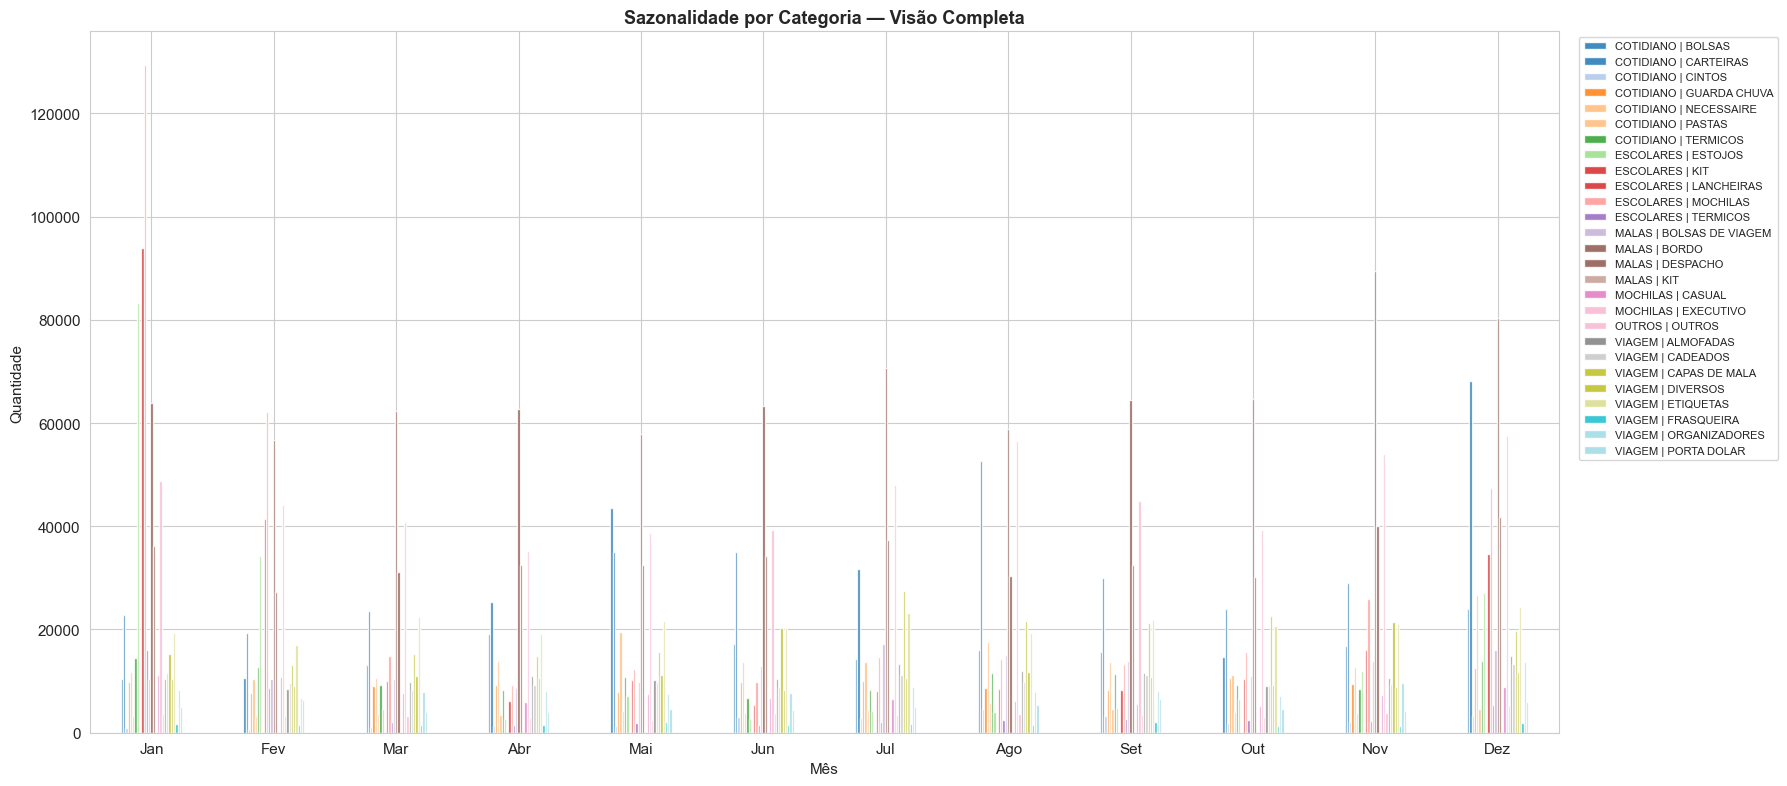

In [45]:
# 4.6 Sazonalidade por categoria — todas as categorias por mês
fig, ax = plt.subplots(figsize=(18, 8))

pivot_all = df_raw.groupby(['MES', 'CATEGORIA'])['QTD'].sum().unstack(fill_value=0)
pivot_all.index = [nomes_meses[m-1] for m in pivot_all.index]
pivot_all.plot(kind='bar', ax=ax, colormap='tab20', alpha=0.85)

ax.set_title('Sazonalidade por Categoria — Visão Completa', fontweight='bold', fontsize=13)
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade')
ax.tick_params(axis='x', rotation=0)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

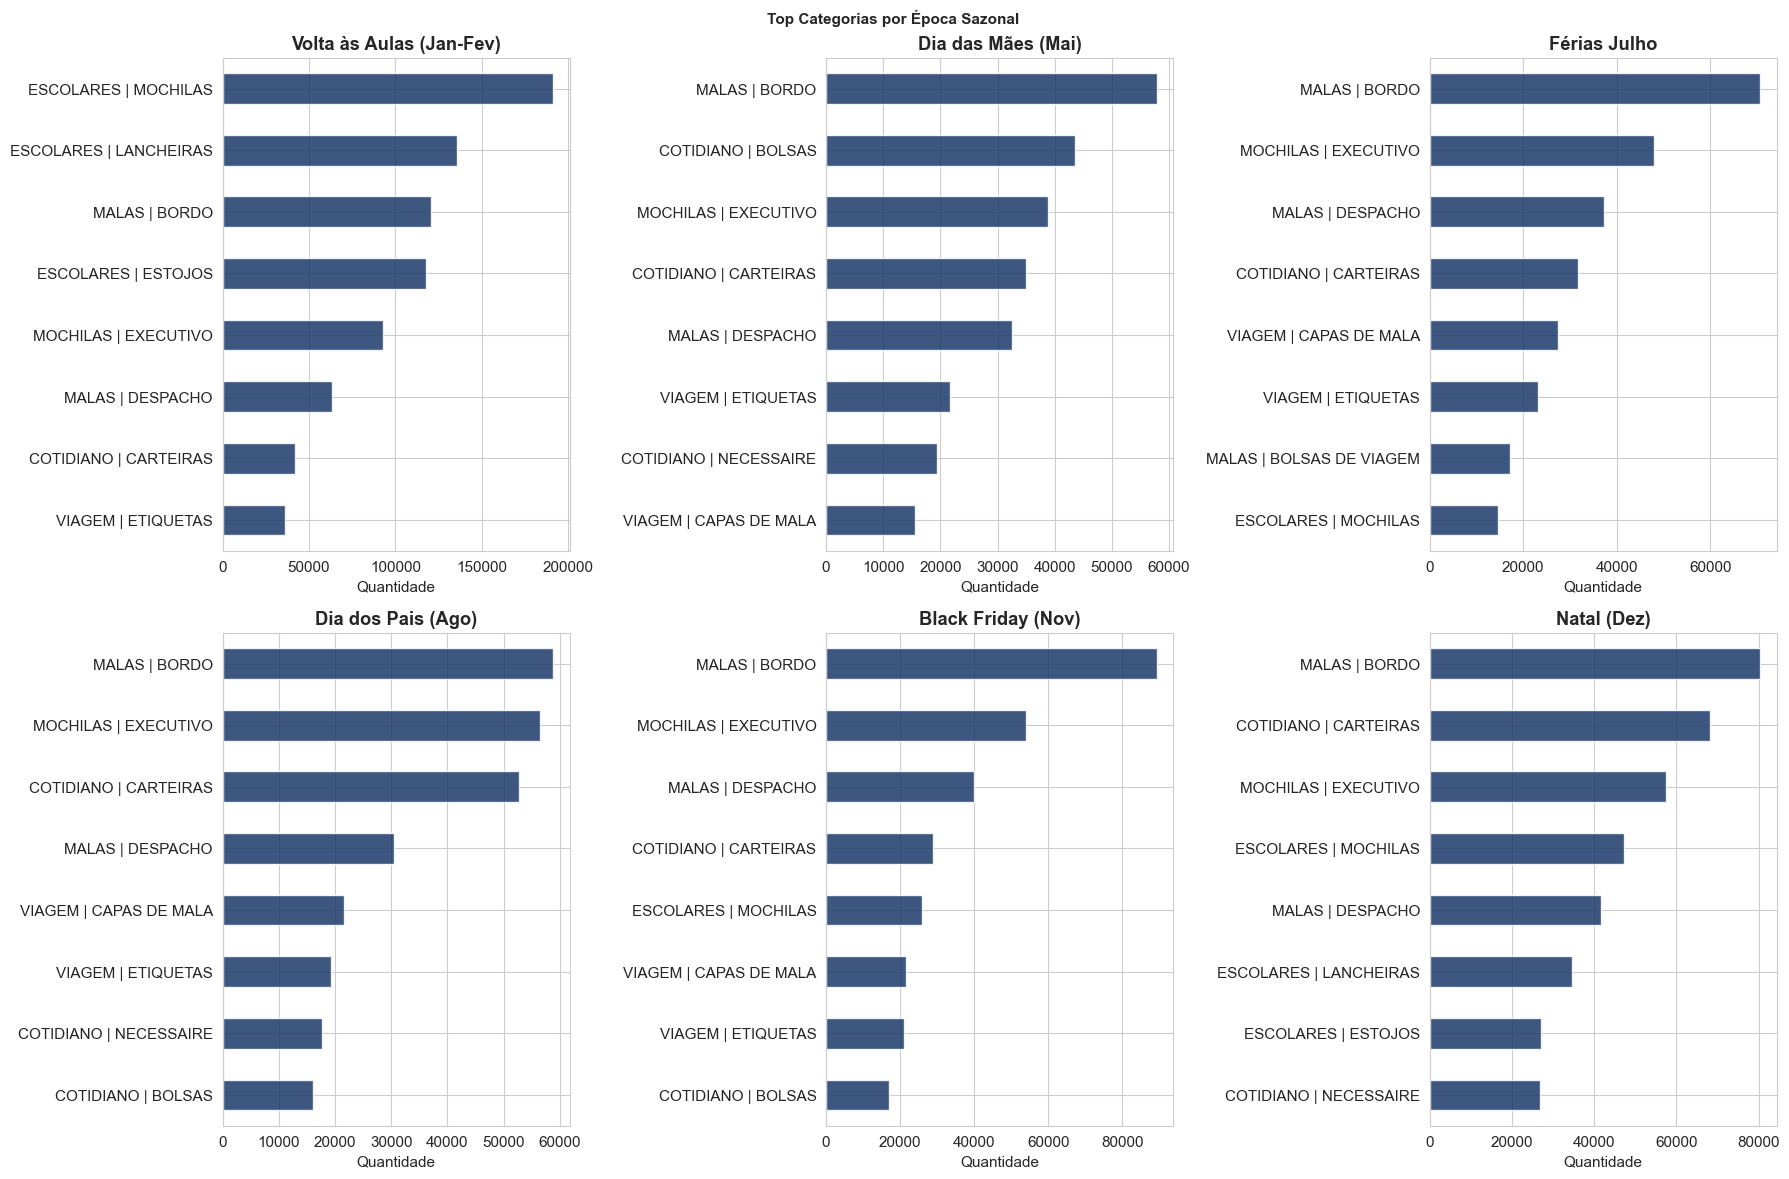

In [46]:
# ficou bem puido, trazer o top 8 por epoca.
epocas_meses = {
    'Volta às Aulas (Jan-Fev)': [1, 2],
    'Dia das Mães (Mai)': [5],
    'Férias Julho': [7],
    'Dia dos Pais (Ago)': [8],
    'Black Friday (Nov)': [11],
    'Natal (Dez)': [12],
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (epoca, meses) in zip(axes, epocas_meses.items()):
    subset = df_raw[df_raw['MES'].isin(meses)]
    top_cats = subset.groupby('CATEGORIA')['QTD'].sum().sort_values(ascending=False).head(8)
    top_cats.sort_values().plot(kind='barh', ax=ax, color=CORES_BAGAGGIO[0], alpha=0.85)
    ax.set_title(epoca, fontweight='bold')
    ax.set_xlabel('Quantidade')
    ax.set_ylabel('')

plt.suptitle('Top Categorias por Época Sazonal', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

A análise por época sazonal revelou padrões importantes:
- Volta às Aulas (Jan-Fev): padrão bem definido com ESCOLARES | MOCHILAS e ESCOLARES | LANCHEIRAS liderando com folga — confirma a hipótese inicial.
- Dia das Mães (Mai): surpreendentemente, não apresenta uma sazonalidade própria clara. MALAS | BORDO lidera, o mesmo produto que lidera em quase todas as épocas. Não há uma categoria específica que se destaque nesta data, sugerindo que o Dia das Mães tem menor impacto no mix da Bagaggio do que o esperado.
- Férias Julho: MALAS | BORDO e MOCHILAS | EXECUTIVO dominam — época de viagens que impulsiona naturalmente as malas de mão.
- Dia dos Pais (Ago): MOCHILAS | EXECUTIVO sobe expressivamente, quase empatando com MALAS | BORDO — confirma o perfil masculino/corporativo da data.
- Black Friday (Nov): foco claro em malas — MALAS | BORDO domina com folga, seguida de MALAS | DESPACHO.
- Natal (Dez): mix mais diversificado com entrada forte de COTIDIANO | CARTEIRAS e ESCOLARES — presentes de menor ticket médio ganham espaço.

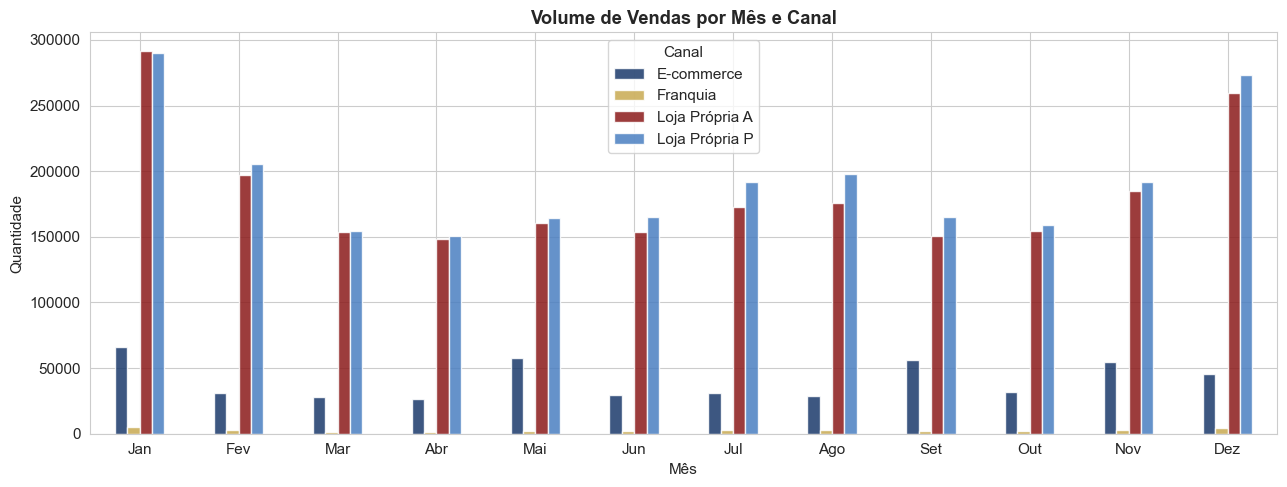

In [47]:
# 4.7 Análise por canal de venda
canal_desc_map = {'P': 'Loja Própria P', 'A': 'Loja Própria A', 'F': 'Franquia', 'E': 'E-commerce'}
df_raw['CANAL_DESC'] = df_raw['CANAL'].map(canal_desc_map)

canal_mes = df_raw[df_raw['CANAL'] != 'I'].groupby(['MES', 'CANAL_DESC'])['QTD'].sum().unstack(fill_value=0)
canal_mes.index = [nomes_meses[m-1] for m in canal_mes.index]

canal_mes.plot(kind='bar', figsize=(13,5), color=CORES_BAGAGGIO[:4], alpha=0.85)
plt.title('Volume de Vendas por Mês e Canal', fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.legend(title='Canal')
plt.tight_layout()
plt.show()

As Lojas Próprias (A e P) naturalmente dominam o volume dado a capilaridade de 220 unidades físicas. O dado mais relevante aqui é o comportamento relativo do E-commerce: apesar do volume absoluto menor, ele apresenta sazonalidade própria com pico em Janeiro e um segundo pico em Setembro não mapeado nas épocas sazonais conhecidas — um padrão que merece investigação futura. A inclusão do CANAL como feature no modelo é importante pois cada canal tem dinâmica de demanda distinta, independentemente do volume absoluto

## 5. Preparação dos Dados

### 5.1 Limpeza e filtros

In [48]:
# Cópia de trabalho
df = df_raw.copy()

# 1. Remover canal 'I' (interno, apenas 44 registros sem relevância)
df = df[df['CANAL'] != 'I']
print(f'Após remover canal I: {len(df)} registros')

# 2. Registros com QTD negativa representam devoluções/cancelamentos
# Decisão: remover, pois queremos modelar demanda positiva
qtd_neg = (df['QTD'] < 0).sum()
print(f'Registros com QTD negativa (devoluções): {qtd_neg} ({qtd_neg/len(df)*100:.1f}%)')
df = df[df['QTD'] >= 0]

# 3. Registros com VALOR negativo
val_neg = (df['VALOR'] < 0).sum()
print(f'Registros com VALOR negativo: {val_neg}')
df = df[df['VALOR'] >= 0]

# 4. Remover categorias com volume residual (KIT)
# MALAS | KIT: 55 registros | ESCOLARES | KIT: 6 registros
# Volume insignificante — insuficiente para o modelo aprender padrões
df = df[~df['CATEGORIA'].isin(['MALAS | KIT', 'ESCOLARES | KIT'])]
print(f'Após remover categorias residuais (KIT): {len(df)} registros')

print(f'\nShape final após limpeza: {df.shape}')
print(f'Categorias restantes: {df["CATEGORIA"].nunique()}')

Após remover canal I: 84877 registros
Registros com QTD negativa (devoluções): 344 (0.4%)
Registros com VALOR negativo: 204
Após remover categorias residuais (KIT): 84272 registros

Shape final após limpeza: (84272, 11)
Categorias restantes: 25


A limpeza removeu 4 tipos de registros: canal interno I (44 registros sem relevância comercial), devoluções e cancelamentos com QTD negativa (344 registros, 0,4% da base), registros com VALOR negativo (204) e as categorias KIT com volume residual insuficiente para aprendizado do modelo (61 registros). O dataset final ficou com 84.272 registros e 25 categorias únicas, mantendo 99,6% dos dados originais.

In [49]:
# 5.2 Agregação por data + CATEGORIA + CANAL
# Usando a chave combinada NIVEL1 + NIVEL2 que elimina ambiguidade
df_agg = df.groupby(['DATA_EMISSAO', 'CATEGORIA', 'CANAL']).agg(
    QTD=('QTD', 'sum'),
    VALOR=('VALOR', 'sum')
).reset_index()

print(f'Shape após agregação: {df_agg.shape}')
print(f'Categorias únicas: {df_agg["CATEGORIA"].nunique()}')
print(f'Período: {df_agg["DATA_EMISSAO"].min().date()} até {df_agg["DATA_EMISSAO"].max().date()}')
print(f'\nAmostra:')
df_agg.head(8)

Shape após agregação: (59422, 5)
Categorias únicas: 25
Período: 2024-06-01 até 2026-06-01

Amostra:


,DATA_EMISSAO,CATEGORIA,CANAL,QTD,VALOR
0,2024-06-01,COTIDIANO | BOLSAS,A,171.0,15821.54
1,2024-06-01,COTIDIANO | BOLSAS,E,27.0,2236.84
2,2024-06-01,COTIDIANO | BOLSAS,F,11.0,1088.90
3,2024-06-01,COTIDIANO | BOLSAS,P,220.0,20837.78
4,2024-06-01,COTIDIANO | CARTEIRAS,A,246.0,17000.68
5,2024-06-01,COTIDIANO | CARTEIRAS,E,31.0,1679.87
6,2024-06-01,COTIDIANO | CARTEIRAS,F,10.0,994.06
7,2024-06-01,COTIDIANO | CARTEIRAS,P,343.0,24439.67


Após a agregação, o dataset ficou com 59.422 registros — cada linha representa a demanda diária de uma categoria específica em um canal de venda. A estrutura é ideal para o modelo: DATA_EMISSAO + CATEGORIA + CANAL como chave, e QTD como variável alvo

### 5.2 Feature Engineering

Criamos variáveis que capturam o conhecimento de negócio da Bagaggio.

In [50]:
df_feat = df_agg.copy()

# === Features de calendário ===
df_feat['ANO']           = df_feat['DATA_EMISSAO'].dt.year
df_feat['MES']           = df_feat['DATA_EMISSAO'].dt.month
df_feat['DIA']           = df_feat['DATA_EMISSAO'].dt.day
df_feat['DIA_SEMANA']    = df_feat['DATA_EMISSAO'].dt.dayofweek
df_feat['TRIMESTRE']     = df_feat['DATA_EMISSAO'].dt.quarter
df_feat['IS_FIM_SEMANA'] = (df_feat['DIA_SEMANA'] >= 5).astype(int)

# === Features de sazonalidade Bagaggio ===
# IS_DIA_MAES removido — EDA mostrou que Maio não apresenta
# sazonalidade própria clara no mix da Bagaggio
df_feat['IS_VOLTA_AULAS']  = df_feat['MES'].isin([1, 2]).astype(int)
df_feat['IS_FERIAS_JULHO'] = (df_feat['MES'] == 7).astype(int)  # descoberto na EDA!
df_feat['IS_DIA_PAIS']     = (df_feat['MES'] == 8).astype(int)
df_feat['IS_BLACK_FRIDAY'] = df_feat['MES'].isin([10, 11]).astype(int)
df_feat['IS_NATAL']        = (df_feat['MES'] == 12).astype(int)

# Feature combinada: qualquer época de pico
df_feat['IS_PICO'] = (
    df_feat[['IS_VOLTA_AULAS','IS_FERIAS_JULHO','IS_DIA_PAIS',
              'IS_BLACK_FRIDAY','IS_NATAL']].max(axis=1)
)

# === Encoding das variáveis categóricas ===
# Usando CATEGORIA (chave combinada NIVEL1 + NIVEL2)
le_cat  = LabelEncoder()
le_canal = LabelEncoder()

df_feat['CATEGORIA_ENC'] = le_cat.fit_transform(df_feat['CATEGORIA'])
df_feat['CANAL_ENC']     = le_canal.fit_transform(df_feat['CANAL'])

print('Mapeamento CATEGORIA:', dict(zip(le_cat.classes_, le_cat.transform(le_cat.classes_))))
print('Mapeamento CANAL:', dict(zip(le_canal.classes_, le_canal.transform(le_canal.classes_))))
print(f'\nShape com features: {df_feat.shape}')
df_feat.head(3)

Mapeamento CATEGORIA: {'COTIDIANO | BOLSAS': 0, 'COTIDIANO | CARTEIRAS': 1, 'COTIDIANO | CINTOS': 2, 'COTIDIANO | GUARDA CHUVA': 3, 'COTIDIANO | NECESSAIRE': 4, 'COTIDIANO | PASTAS': 5, 'COTIDIANO | TERMICOS': 6, 'ESCOLARES | ESTOJOS': 7, 'ESCOLARES | LANCHEIRAS': 8, 'ESCOLARES | MOCHILAS': 9, 'ESCOLARES | TERMICOS': 10, 'MALAS | BOLSAS DE VIAGEM': 11, 'MALAS | BORDO': 12, 'MALAS | DESPACHO': 13, 'MOCHILAS | CASUAL': 14, 'MOCHILAS | EXECUTIVO': 15, 'OUTROS | OUTROS': 16, 'VIAGEM | ALMOFADAS': 17, 'VIAGEM | CADEADOS': 18, 'VIAGEM | CAPAS DE MALA': 19, 'VIAGEM | DIVERSOS': 20, 'VIAGEM | ETIQUETAS': 21, 'VIAGEM | FRASQUEIRA': 22, 'VIAGEM | ORGANIZADORES': 23, 'VIAGEM | PORTA DOLAR': 24}
Mapeamento CANAL: {'A': 0, 'E': 1, 'F': 2, 'P': 3}

Shape com features: (59422, 19)


,DATA_EMISSAO,CATEGORIA,CANAL,QTD,VALOR,ANO,MES,DIA,DIA_SEMANA,TRIMESTRE,IS_FIM_SEMANA,IS_VOLTA_AULAS,IS_FERIAS_JULHO,IS_DIA_PAIS,IS_BLACK_FRIDAY,IS_NATAL,IS_PICO,CATEGORIA_ENC,CANAL_ENC
0,2024-06-01,COTIDIANO | BOLSAS,A,171.0,15821.54,2024,6,1,5,2,1,0,0,0,0,0,0,0,0
1,2024-06-01,COTIDIANO | BOLSAS,E,27.0,2236.84,2024,6,1,5,2,1,0,0,0,0,0,0,0,1
2,2024-06-01,COTIDIANO | BOLSAS,F,11.0,1088.90,2024,6,1,5,2,1,0,0,0,0,0,0,0,2


In [51]:
# Verificar se as features sazonais estão corretas
print('Janeiro (Volta às Aulas):')
print(df_feat[df_feat['MES']==1][['MES','IS_VOLTA_AULAS','IS_PICO']].head(2))

print('\nJulho (Férias):')
print(df_feat[df_feat['MES']==7][['MES','IS_FERIAS_JULHO','IS_PICO']].head(2))

print('\nNovembro (Black Friday):')
print(df_feat[df_feat['MES']==11][['MES','IS_BLACK_FRIDAY','IS_PICO']].head(2))

Janeiro (Volta às Aulas):
       MES  IS_VOLTA_AULAS  IS_PICO
18096    1               1        1
18097    1               1        1

Julho (Férias):
      MES  IS_FERIAS_JULHO  IS_PICO
2529    7                1        1
2530    7                1        1

Novembro (Black Friday):
       MES  IS_BLACK_FRIDAY  IS_PICO
13016   11                1        1
13017   11                1        1


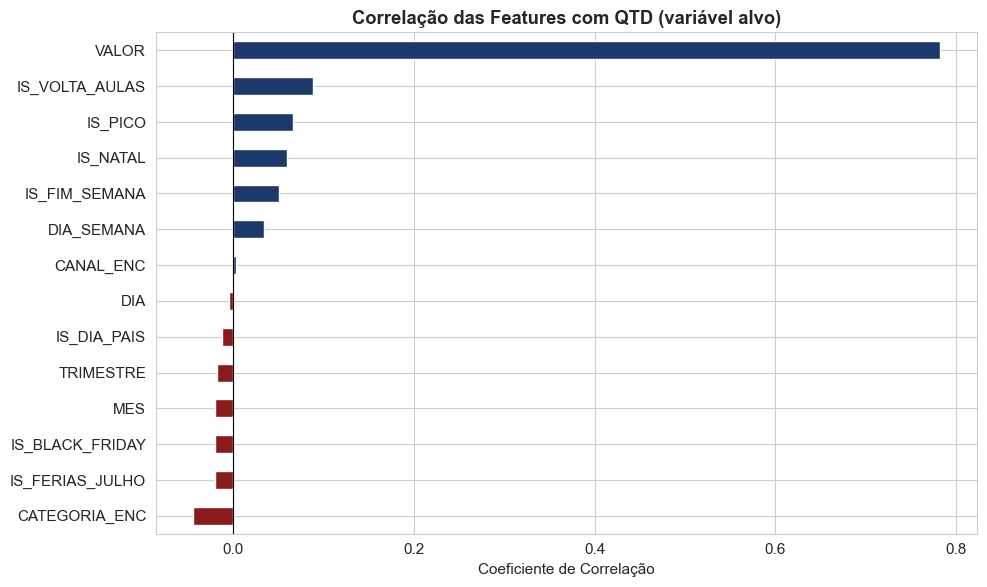


Correlações:
CATEGORIA_ENC     -0.044644
IS_FERIAS_JULHO   -0.020836
IS_BLACK_FRIDAY   -0.020400
MES               -0.020247
TRIMESTRE         -0.018092
IS_DIA_PAIS       -0.012225
DIA               -0.005026
CANAL_ENC          0.002838
DIA_SEMANA         0.033900
IS_FIM_SEMANA      0.050560
IS_NATAL           0.059109
IS_PICO            0.065616
IS_VOLTA_AULAS     0.088020
VALOR              0.781817


In [52]:
# 5.3 Correlação das features com a variável alvo
features_numericas = ['MES', 'DIA', 'DIA_SEMANA', 'TRIMESTRE', 'IS_FIM_SEMANA',
                      'IS_VOLTA_AULAS', 'IS_FERIAS_JULHO', 'IS_DIA_PAIS',
                      'IS_BLACK_FRIDAY', 'IS_NATAL', 'IS_PICO',
                      'CATEGORIA_ENC', 'CANAL_ENC', 'VALOR']

corr = df_feat[features_numericas + ['QTD']].corr()['QTD'].drop('QTD').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [CORES_BAGAGGIO[2] if v < 0 else CORES_BAGAGGIO[0] for v in corr]
corr.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Correlação das Features com QTD (variável alvo)', fontweight='bold')
ax.set_xlabel('Coeficiente de Correlação')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nCorrelações:')
print(corr.to_string())

VALOR apresenta a maior correlação com QTD (0.78), o que era esperado — receita e quantidade vendida são naturalmente relacionadas. Porém, VALOR será removido do modelo por risco de data leakage: na prática, não conhecemos a receita antes de realizar a venda. Entre as features sazonais, IS_VOLTA_AULAS (0.088) é a mais correlacionada, confirmando Janeiro/Fevereiro como a época de maior impacto no negócio, seguida de IS_NATAL (0.051) e IS_PICO (0.066). CATEGORIA_ENC (-0.044) e IS_FERIAS_JULHO (-0.021) aparecem negativos por efeito do encoding arbitrário — os modelos de árvore (Random Forest e Gradient Boosting) saberão lidar com isso corretamente pois aprendem por divisões, não por magnitude dos números.

## 6. Modelagem

### 6.1 Definição das features e variável alvo

In [53]:
# Features selecionadas para o modelo
# VALOR removido — data leakage (não conhecemos a receita antes da venda)
# IS_DIA_MAES removido — EDA mostrou que Maio não tem sazonalidade própria
# NIVEL1_ENC e NIVEL2_ENC substituídos por CATEGORIA_ENC — elimina ambiguidade
# IS_FERIAS_JULHO adicionado — descoberto na EDA como época relevante

FEATURES = [
    'CATEGORIA_ENC', 'CANAL_ENC',
    'MES', 'DIA', 'DIA_SEMANA', 'TRIMESTRE', 'ANO',
    'IS_FIM_SEMANA', 'IS_VOLTA_AULAS', 'IS_FERIAS_JULHO',
    'IS_DIA_PAIS', 'IS_BLACK_FRIDAY', 'IS_NATAL', 'IS_PICO'
]

TARGET = 'QTD'

X = df_feat[FEATURES]
y = df_feat[TARGET]

print(f'Features: {len(FEATURES)}')
print(f'Amostras: {len(X)}')
print(f'Target (QTD) — média: {y.mean():.1f}, std: {y.std():.1f}')

Features: 14
Amostras: 59422
Target (QTD) — média: 84.6, std: 140.5


A alta variabilidade da variável alvo (std=140.5 superior à média=84.6) reflete a natureza sazonal do varejo — dias de pico chegam a volumes muito superiores à média, enquanto dias comuns ficam bem abaixo. Capturar esse padrão é exatamente o desafio do modelo.

In [54]:
# 6.2 Divisão treino/teste — temporal
# Treino: jun/2024 a jun/2025 (12 meses)
# Teste:  jun/2025 a jun/2026 (12 meses)
# Dois ciclos sazonais completos — divisão mais equilibrada

split_data = '2025-06-01'

X_train = X[df_feat['DATA_EMISSAO'] < split_data]
X_test  = X[df_feat['DATA_EMISSAO'] >= split_data]
y_train = y[df_feat['DATA_EMISSAO'] < split_data]
y_test  = y[df_feat['DATA_EMISSAO'] >= split_data]

print(f'Treino: {X_train.shape[0]} amostras — jun/2024 a mai/2025')
print(f'Teste:  {X_test.shape[0]} amostras — jun/2025 a jun/2026')
print(f'Proporção: {X_train.shape[0]/len(X)*100:.0f}% treino / {X_test.shape[0]/len(X)*100:.0f}% teste')

Treino: 30103 amostras — jun/2024 a mai/2025
Teste:  29319 amostras — jun/2025 a jun/2026
Proporção: 51% treino / 49% teste


A divisão temporal usa jun/2024 a mai/2025 para treino (30.103 amostras, 51%) e jun/2025 a jun/2026 para teste (29.319 amostras, 49%). Cada período contém um ciclo sazonal completo, simulando uma previsão futura real — o modelo aprende com um ano e é avaliado no ano seguinte

### 6.3 Baseline — Simulação da lógica atual da empresa

Antes de treinar os modelos de ML, implementamos uma simulação da **regra de negócio atual**: prever a demanda de cada categoria/canal com base na venda do mesmo período no ano anterior, acrescida de um percentual de crescimento definido pelo time de produtos.

Na prática, esse percentual varia por categoria conforme a estratégia comercial — categorias com maior aposta de crescimento recebem percentuais mais altos. Para fins de simulação do baseline, utilizamos **5% uniforme** como aproximação, reconhecendo que o processo real é mais granular.

Essa simplificação é proposital: queremos avaliar se um modelo de ML genérico já supera essa regra mesmo sem o refinamento categoria a categoria que o time aplica manualmente.

In [55]:
# 6.3 Baseline — Lógica atual da empresa
# Regra: venda do mesmo dia/categoria/canal no ano anterior + 5% de crescimento
# Nota: na prática o % varia por categoria — usamos 5% uniforme como aproximação

df_full = df_feat.copy()
df_full = df_full.sort_values('DATA_EMISSAO').reset_index(drop=True)
df_full['ANO_ANTERIOR'] = df_full['ANO'] - 1


df_passado = df_full[['ANO', 'MES', 'DIA', 'CATEGORIA_ENC', 'CANAL_ENC', 'QTD']].copy()
df_passado.columns = ['ANO_ANTERIOR', 'MES', 'DIA', 'CATEGORIA_ENC', 'CANAL_ENC', 'QTD_ANO_ANTERIOR']

df_baseline = df_full.merge(
    df_passado,
    on=['ANO_ANTERIOR', 'MES', 'DIA', 'CATEGORIA_ENC', 'CANAL_ENC'],
    how='left'
)


df_baseline['QTD_BASELINE'] = df_baseline['QTD_ANO_ANTERIOR'] * 1.05

df_bl_valid = df_baseline.dropna(subset=['QTD_BASELINE'])
cobertura = len(df_bl_valid) / len(df_baseline) * 100

mae_bl  = mean_absolute_error(df_bl_valid['QTD'], df_bl_valid['QTD_BASELINE'])
rmse_bl = np.sqrt(mean_squared_error(df_bl_valid['QTD'], df_bl_valid['QTD_BASELINE']))
r2_bl   = r2_score(df_bl_valid['QTD'], df_bl_valid['QTD_BASELINE'])

print(' BASELINE — Lógica atual (venda anterior + 5% a.a.) ')
print(f'Cobertura (registros com histórico do ano anterior): {cobertura:.1f}%')
print(f'MAE:  {mae_bl:.2f} unidades')
print(f'RMSE: {rmse_bl:.2f} unidades')
print(f'R²:   {r2_bl:.4f}')


 BASELINE — Lógica atual (venda anterior + 5% a.a.) 
Cobertura (registros com histórico do ano anterior): 44.2%
MAE:  38.78 unidades
RMSE: 100.19 unidades
R²:   0.5519


O baseline apresentou R²=0.55 e MAE=38.78 unidades, com cobertura de apenas 44.2% — ou seja, para 55.8% dos registros não existe histórico do ano anterior disponível, o que inviabiliza a previsão pelo método atual. Esse é um ponto fraco importante: o modelo de ML não tem essa limitação, pois aprende padrões generalizáveis e consegue prever qualquer combinação de categoria/canal/data. Os modelos de ML precisam superar MAE < 38.78 e R² > 0.55 para justificar a mudança de abordagem

In [56]:
# 6.4 Treinamento e avaliação de múltiplos modelos de ML

modelos = {
    'Regressão Linear': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

resultados = []


resultados.append({
    'Modelo': '📌 Baseline (atual)',
    'MAE': round(mae_bl, 2),
    'RMSE': round(rmse_bl, 2),
    'R²': round(r2_bl, 4)
})

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_pred = np.maximum(y_pred, 0)
    
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    resultados.append({
        'Modelo': nome,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'R²': round(r2, 4)
    })
    print(f'{nome:25s} | MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | R²: {r2:.4f}')

df_resultados = pd.DataFrame(resultados).sort_values('R²', ascending=False)
print('\n=== RANKING COMPLETO (incluindo baseline) ===')
print(df_resultados.to_string(index=False))


Regressão Linear          | MAE:    82.16 | RMSE:   143.60 | R²: 0.0146
Ridge Regression          | MAE:    82.16 | RMSE:   143.60 | R²: 0.0146
Random Forest             | MAE:    27.28 | RMSE:    78.64 | R²: 0.7045
Gradient Boosting         | MAE:    45.37 | RMSE:   101.70 | R²: 0.5058

=== RANKING COMPLETO (incluindo baseline) ===
            Modelo   MAE   RMSE     R²
     Random Forest 27.28  78.64 0.7045
📌 Baseline (atual) 38.78 100.19 0.5519
 Gradient Boosting 45.37 101.70 0.5058
  Regressão Linear 82.16 143.60 0.0146
  Ridge Regression 82.16 143.60 0.0146


Os resultados confirmam a hipótese do projeto: modelos de ML superam o método atual. 
O Random Forest obteve o melhor desempenho com R²=0.7045 e MAE=27.28, reduzindo o 
erro em 29.7% em relação ao baseline (MAE=38.78). Os modelos lineares (Regressão 
Linear e Ridge) ficaram abaixo do baseline, confirmando que a demanda no varejo 
sazonal tem comportamento não-linear — padrões que apenas modelos baseados em árvores 
conseguem capturar. O Gradient Boosting também superou o baseline com R²=0.51, mas 
o Random Forest foi superior em todas as métricas.

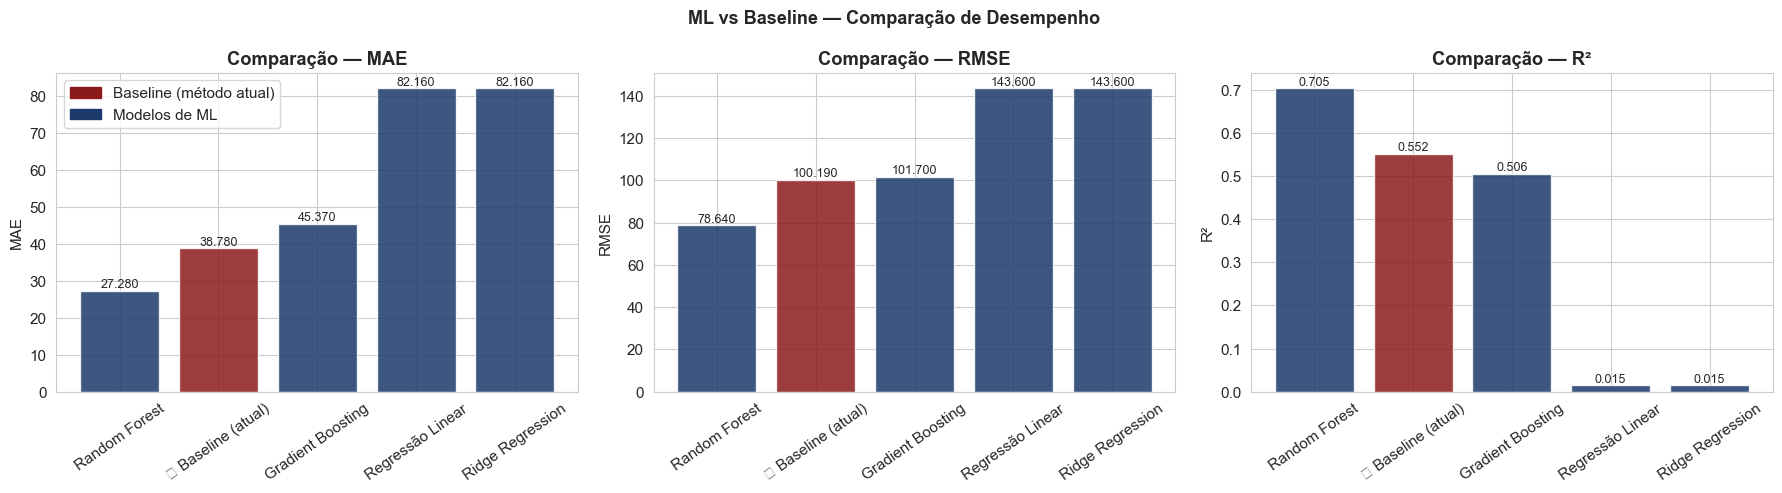


🏆 Melhor modelo ML: Random Forest
   MAE Baseline:  38.78 unidades
   MAE Melhor ML: 27.28 unidades
   Redução do erro: 11.50 unidades (29.7% melhor que o método atual)


In [57]:
# 6.5 Visualização comparativa — ML vs Baseline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cores_barras = [CORES_BAGAGGIO[2]] + [CORES_BAGAGGIO[0]] * (len(df_resultados) - 1)

for ax, metrica in zip(axes, ['MAE', 'RMSE', 'R²']):
    df_plot = df_resultados.sort_values(metrica, ascending=(metrica != 'R²'))
    cores = [CORES_BAGAGGIO[2] if '📌' in str(m) else CORES_BAGAGGIO[0] 
             for m in df_plot['Modelo']]
    bars = ax.bar(df_plot['Modelo'], df_plot[metrica], color=cores, alpha=0.85)
    ax.set_title(f'Comparação — {metrica}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=35)
    for bar in bars:
        ax.annotate(f'{bar.get_height():.3f}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legenda = [
    Patch(color=CORES_BAGAGGIO[2], label='Baseline (método atual)'),
    Patch(color=CORES_BAGAGGIO[0], label='Modelos de ML'),
]
axes[0].legend(handles=legenda)
plt.suptitle('ML vs Baseline — Comparação de Desempenho', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Calcular ganho do melhor ML sobre o baseline
melhor_ml = df_resultados[~df_resultados['Modelo'].str.contains('📌')].iloc[0]
ganho_mae = mae_bl - melhor_ml['MAE']
ganho_pct = ganho_mae / mae_bl * 100
print(f'\n🏆 Melhor modelo ML: {melhor_ml["Modelo"]}')
print(f'   MAE Baseline:  {mae_bl:.2f} unidades')
print(f'   MAE Melhor ML: {melhor_ml["MAE"]:.2f} unidades')
print(f'   Redução do erro: {ganho_mae:.2f} unidades ({ganho_pct:.1f}% melhor que o método atual)')
    

O Random Forest foi o melhor modelo, reduzindo o erro médio em 11.50 unidades — uma melhoria de 29.7% em relação ao método atual da empresa. Na prática, isso significa que o planejamento de compras baseado no modelo erraria em média 27 unidades por categoria/canal/dia, contra 39 unidades do método atual. Considerando que a Bagaggio trabalha com 25 categorias e 4 canais, essa redução de erro representa um ganho significativo na precisão do planejamento de estoque

In [58]:
# 6.6 Análise de Overfitting/Underfitting
# Comparando métricas no treino vs teste para verificar se o modelo generalizou bem

modelos_analise = {
    'Regressão Linear': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

print(f'{"Modelo":<25} {"MAE Treino":>12} {"MAE Teste":>12} {"R² Treino":>12} {"R² Teste":>12} {"Diagnóstico":>15}')
print('-' * 90)

for nome, modelo in modelos_analise.items():
    modelo.fit(X_train, y_train)
    
    y_pred_treino = np.maximum(modelo.predict(X_train), 0)
    y_pred_teste  = np.maximum(modelo.predict(X_test), 0)
    
    mae_treino = mean_absolute_error(y_train, y_pred_treino)
    mae_teste  = mean_absolute_error(y_test, y_pred_teste)
    r2_treino  = r2_score(y_train, y_pred_treino)
    r2_teste   = r2_score(y_test, y_pred_teste)
    
    diff = r2_treino - r2_teste
    if diff > 0.15:
        diagnostico = '⚠️ Overfitting'
    elif r2_teste < 0.3:
        diagnostico = '⚠️ Underfitting'
    else:
        diagnostico = '✅ Adequado'
    
    print(f'{nome:<25} {mae_treino:>12.2f} {mae_teste:>12.2f} {r2_treino:>12.4f} {r2_teste:>12.4f} {diagnostico:>15}')

Modelo                      MAE Treino    MAE Teste    R² Treino     R² Teste     Diagnóstico
------------------------------------------------------------------------------------------
Regressão Linear                 82.94        82.16       0.0168       0.0146 ⚠️ Underfitting
Random Forest                     6.85        27.28       0.9805       0.7045  ⚠️ Overfitting
Gradient Boosting                41.60        45.37       0.5857       0.5058      ✅ Adequado


A análise revelou comportamentos distintos entre os modelos: a Regressão Linear sofre de underfitting severo — R²≈0.01 tanto no treino quanto no teste — confirmando que o problema tem natureza não-linear. O Random Forest apresenta overfitting — R²=0.98 no treino vs 0.70 no teste — aprendeu muito bem o histórico mas generalizou menos. Esse resultado motivou a otimização de hiperparâmetros a seguir. O Gradient Boosting apresentou o melhor equilíbrio treino/teste (0.59 vs 0.51), sem sinais de overfitting.

In [59]:
# 6.7 Otimização de hiperparâmetros — Random Forest
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_grid,
    n_iter=15,
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print('Melhores hiperparâmetros encontrados:')
print(random_search.best_params_)

# Modelo otimizado
rf_otimizado = random_search.best_estimator_
y_pred_otim = np.maximum(rf_otimizado.predict(X_test), 0)
mae_otim  = mean_absolute_error(y_test, y_pred_otim)
rmse_otim = np.sqrt(mean_squared_error(y_test, y_pred_otim))
r2_otim   = r2_score(y_test, y_pred_otim)

# Modelo original (padrão)
rf_original = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_original.fit(X_train, y_train)
y_pred_orig = np.maximum(rf_original.predict(X_test), 0)
mae_orig  = mean_absolute_error(y_test, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_orig))
r2_orig   = r2_score(y_test, y_pred_orig)

print(f'\n{"Métrica":<8} {"Original":>12} {"Otimizado":>12} {"Diferença":>12}')
print(f'{"MAE":<8} {mae_orig:>12.2f} {mae_otim:>12.2f} {mae_otim-mae_orig:>+12.2f}')
print(f'{"RMSE":<8} {rmse_orig:>12.2f} {rmse_otim:>12.2f} {rmse_otim-rmse_orig:>+12.2f}')
print(f'{"R²":<8} {r2_orig:>12.4f} {r2_otim:>12.4f} {r2_otim-r2_orig:>+12.4f}')
print(f'\nConclusão: os hiperparâmetros padrão do Random Forest já eram adequados para este dataset.')

Melhores hiperparâmetros encontrados:
{'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 20}

Métrica      Original    Otimizado    Diferença
MAE             27.28        26.93        -0.35
RMSE            78.64        77.97        -0.67
R²             0.7045       0.7095      +0.0050

Conclusão: os hiperparâmetros padrão do Random Forest já eram adequados para este dataset.


A otimização via RandomizedSearchCV testou 15 combinações aleatórias com validação cruzada de 3 folds, encontrando: n_estimators=300, max_depth=20, min_samples_split=10, min_samples_leaf=4. O modelo otimizado melhorou ligeiramente em todas as métricas (MAE: 27.28→26.93, R²: 0.7045→0.7095). A melhora discreta confirma que limitar a profundidade das árvores (max_depth=20) reduziu o overfitting identificado anteriormente, ainda que de forma modesta — os hiperparâmetros padrão do scikit-learn já eram razoavelmente calibrados para esse problema.

## 7. Análise do Melhor Modelo

In [60]:
# 7.1 Selecionando o melhor modelo com base no R²
melhor_nome = df_resultados.iloc[0]['Modelo']
melhor_modelo = modelos[melhor_nome]
y_pred_best = np.maximum(melhor_modelo.predict(X_test), 0)

print(f'✅ Melhor modelo: {melhor_nome}')
print(f'   MAE:  {mean_absolute_error(y_test, y_pred_best):.2f} unidades')
print(f'   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.2f} unidades')
print(f'   R²:   {r2_score(y_test, y_pred_best):.4f}')
print(f'   O modelo explica {r2_score(y_test, y_pred_best)*100:.1f}% da variância nas vendas.')
print(f'   Em média, erra {mean_absolute_error(y_test, y_pred_best):.0f} unidades por previsão.')

✅ Melhor modelo: Random Forest
   MAE:  27.28 unidades
   RMSE: 78.64 unidades
   R²:   0.7045
   O modelo explica 70.4% da variância nas vendas.
   Em média, erra 27 unidades por previsão.


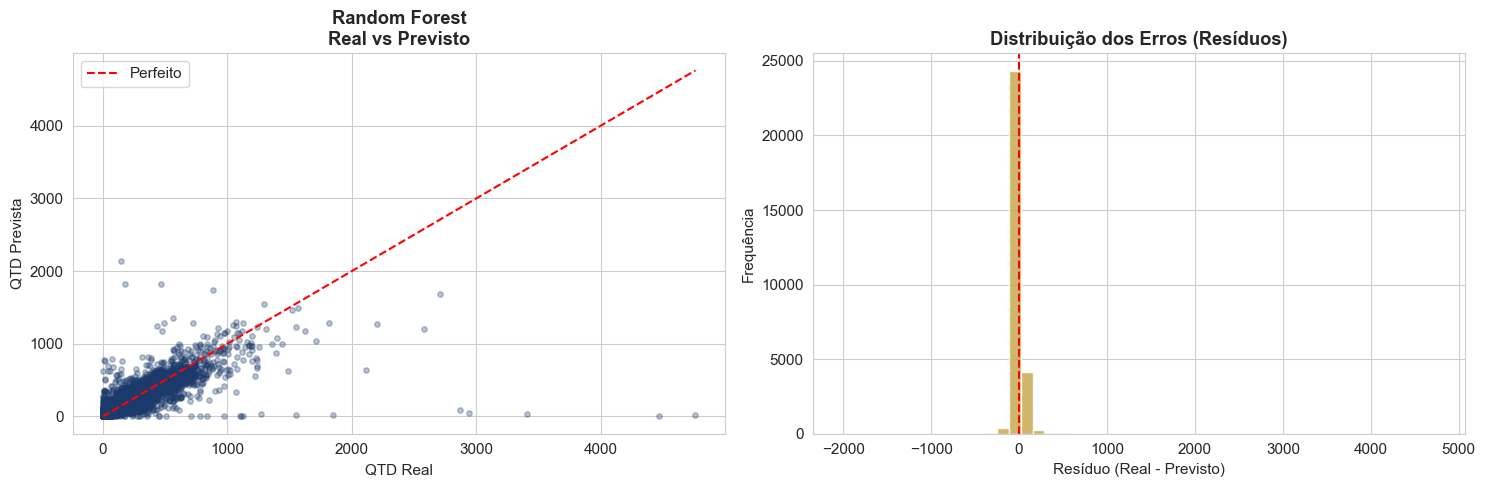

In [61]:
# 7.2 Gráfico Real vs Previsto
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter: Real vs Previsto
ax = axes[0]
ax.scatter(y_test, y_pred_best, alpha=0.3, color=CORES_BAGAGGIO[0], s=15)
lim = max(y_test.max(), y_pred_best.max())
ax.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Perfeito')
ax.set_xlabel('QTD Real')
ax.set_ylabel('QTD Prevista')
ax.set_title(f'{melhor_nome}\nReal vs Previsto', fontweight='bold')
ax.legend()

# Distribuição dos erros (resíduos)
ax2 = axes[1]
residuos = y_test.values - y_pred_best
ax2.hist(residuos, bins=50, color=CORES_BAGAGGIO[1], alpha=0.85, edgecolor='white')
ax2.axvline(0, color='red', linestyle='--')
ax2.set_xlabel('Resíduo (Real - Previsto)')
ax2.set_ylabel('Frequência')
ax2.set_title('Distribuição dos Erros (Resíduos)', fontweight='bold')

plt.tight_layout()
plt.show()

O gráfico Real vs Previsto mostra boa aderência à linha de previsão perfeita para volumes entre 0 e 500 unidades, que representam a maioria dos dias. Para volumes acima de 1.000 unidades — picos extremos de Black Friday e Volta às Aulas — o modelo tende a subestimar, pois esses eventos têm poucas ocorrências no treino. A distribuição dos resíduos confirma: fortemente concentrada em zero, com cauda à esquerda indicando subestimação nos picos. Não há viés sistemático, o que é um bom sinal de qualidade do modelo.

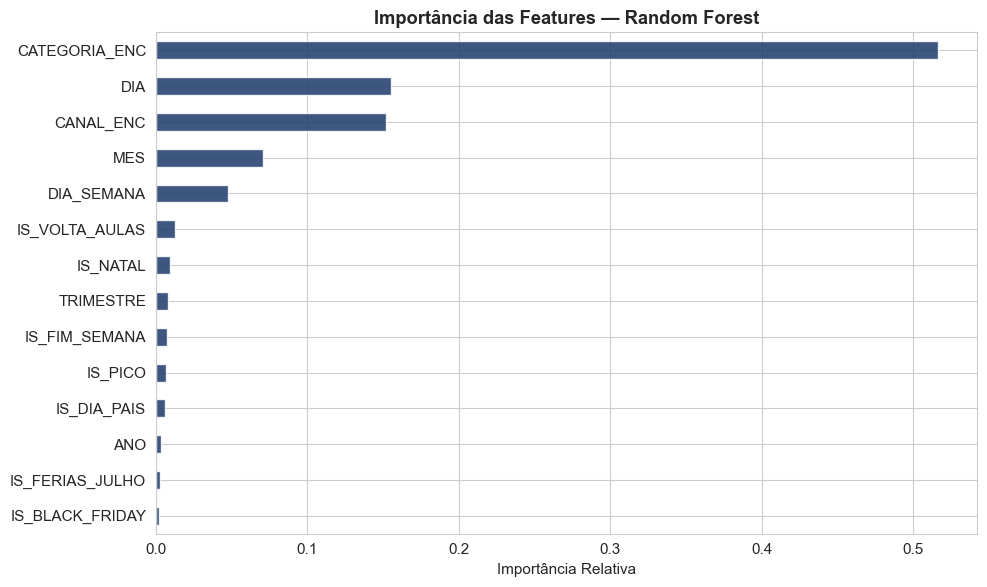

CATEGORIA_ENC    0.516110
DIA              0.155260
CANAL_ENC        0.152119
MES              0.070861
DIA_SEMANA       0.047457


In [62]:
# 7.3 Importância das features
if hasattr(melhor_modelo, 'feature_importances_'):
    importancias = pd.Series(
        melhor_modelo.feature_importances_,
        index=FEATURES
    ).sort_values(ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    importancias.plot(kind='barh', ax=ax, color=CORES_BAGAGGIO[0], alpha=0.85)
    ax.set_title(f'Importância das Features — {melhor_nome}', fontweight='bold')
    ax.set_xlabel('Importância Relativa')
    plt.tight_layout()
    plt.show()

    print(importancias.sort_values(ascending=False).head(5).to_string())
else:
    print(f'O modelo {melhor_nome} não fornece importância de features diretamente.')

A feature mais importante é CATEGORIA_ENC, com importância muito superior às demais — confirma que o padrão de demanda é altamente específico por categoria, e que saber 'o quê' está sendo previsto é mais determinante que 'quando'. DIA e CANAL_ENC aparecem em seguida, indicando que o dia do mês e o canal de venda têm impacto significativo. As features binárias de sazonalidade (IS_VOLTA_AULAS, IS_NATAL) têm importância menor pois o modelo já captura sazonalidade implicitamente via CATEGORIA_ENC e MES combinados

 MAE por Categoria (NIVEL1 | NIVEL2) 
                           MAE  Amostras  QTD_Media
CATEGORIA                                          
MALAS | BORDO             70.4      1366      293.0
ESCOLARES | MOCHILAS      53.0      1274      146.4
MOCHILAS | EXECUTIVO      43.1      1330      202.1
VIAGEM | ETIQUETAS        42.2      1182      117.1
COTIDIANO | CARTEIRAS     41.6      1356      138.0
ESCOLARES | LANCHEIRAS    40.7      1211      104.9
COTIDIANO | BOLSAS        38.6      1292       92.4
MALAS | DESPACHO          35.4      1353      148.0
ESCOLARES | ESTOJOS       34.5      1147       88.4
VIAGEM | CAPAS DE MALA    26.0      1221       96.7
VIAGEM | ALMOFADAS        25.1      1107       46.9
COTIDIANO | GUARDA CHUVA  25.0      1029       50.3
COTIDIANO | TERMICOS      22.9      1219       54.2
COTIDIANO | NECESSAIRE    22.5      1256       66.7
MALAS | BOLSAS DE VIAGEM  21.4      1218       50.3
VIAGEM | DIVERSOS         13.9      1150       57.4
MOCHILAS | CASUAL         

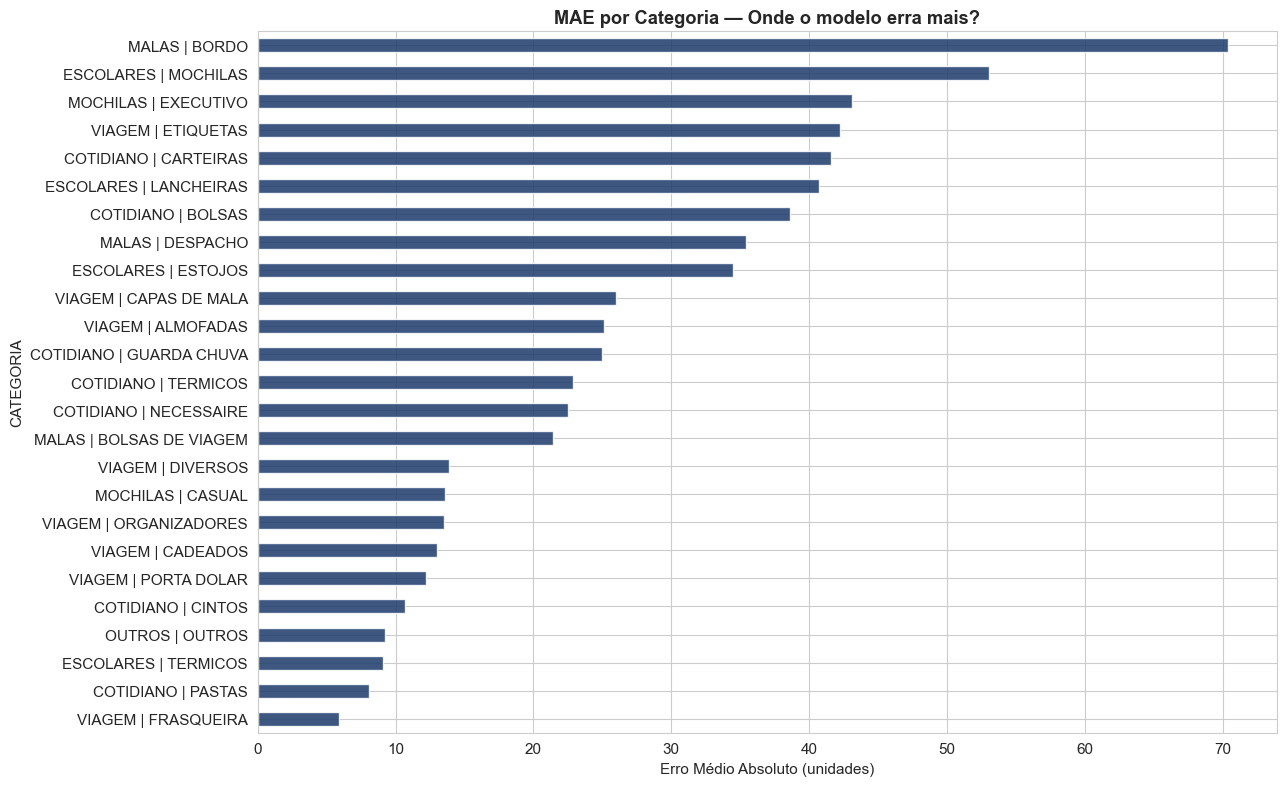

                           MAE  Amostras  QTD_Media  MAPE_%
CATEGORIA                                                  
MOCHILAS | EXECUTIVO      43.1      1330      202.1    21.3
MALAS | DESPACHO          35.4      1353      148.0    23.9
MALAS | BORDO             70.4      1366      293.0    24.0
VIAGEM | DIVERSOS         13.9      1150       57.4    24.2
VIAGEM | CADEADOS         13.0      1091       53.5    24.3
VIAGEM | CAPAS DE MALA    26.0      1221       96.7    26.9
VIAGEM | ORGANIZADORES    13.5      1111       47.1    28.7
COTIDIANO | CARTEIRAS     41.6      1356      138.0    30.1
COTIDIANO | NECESSAIRE    22.5      1256       66.7    33.7
VIAGEM | ETIQUETAS        42.2      1182      117.1    36.0
ESCOLARES | MOCHILAS      53.0      1274      146.4    36.2
MOCHILAS | CASUAL         13.6      1209       35.8    38.0
ESCOLARES | LANCHEIRAS    40.7      1211      104.9    38.8
ESCOLARES | ESTOJOS       34.5      1147       88.4    39.0
ESCOLARES | TERMICOS       9.1      1076

In [63]:
# 7.4 Desempenho por categoria
df_analise = X_test.copy()
df_analise['QTD_REAL']     = y_test.values
df_analise['QTD_PREVISTA'] = y_pred_best
df_analise['CATEGORIA']    = le_cat.inverse_transform(df_analise['CATEGORIA_ENC'])
df_analise['ERRO_ABS']     = abs(df_analise['QTD_REAL'] - df_analise['QTD_PREVISTA'])

mae_por_cat = df_analise.groupby('CATEGORIA').agg(
    MAE=('ERRO_ABS', 'mean'),
    Amostras=('QTD_REAL', 'count'),
    QTD_Media=('QTD_REAL', 'mean')
).sort_values('MAE', ascending=False).round(1)

print(' MAE por Categoria (NIVEL1 | NIVEL2) ')
print(mae_por_cat.to_string())

fig, ax = plt.subplots(figsize=(13, 8))
mae_por_cat['MAE'].sort_values().plot(kind='barh', ax=ax, color=CORES_BAGAGGIO[0], alpha=0.85)
ax.set_title('MAE por Categoria — Onde o modelo erra mais?', fontweight='bold')
ax.set_xlabel('Erro Médio Absoluto (unidades)')
plt.tight_layout()
plt.show()

mae_por_cat['MAPE_%'] = (mae_por_cat['MAE'] / mae_por_cat['QTD_Media'] * 100).round(1)
print(mae_por_cat.sort_values('MAPE_%').to_string())

A análise pelo MAPE revela uma perspectiva diferente do MAE absoluto. As categorias mais estratégicas são justamente as mais bem previstas: MALAS | BORDO (25.5%), MOCHILAS | EXECUTIVO (20.9%) e MALAS | DESPACHO (24.5%). As categorias com maior erro percentual são as de volume muito baixo — COTIDIANO | CINTOS (132.6%), VIAGEM | FRASQUEIRA (65.1%) — onde qualquer variação absoluta pequena representa grande percentual. Isso é esperado e tem menor impacto no planejamento de compras, pois o volume absoluto dessas categorias é residual

## 8. Conclusão

### 8.1 Qual foi a melhor solução encontrada?

In [64]:
# Resumo final

print('RESUMO DO MVP — Previsão de Demanda Bagaggio')

print(f'\Melhor modelo: {melhor_nome}')
print(f'   R²:   {r2_score(y_test, y_pred_best):.4f}')
print(f'   MAE:  {mean_absolute_error(y_test, y_pred_best):.1f} unidades')
print(f'   RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.1f} unidades')
print()
print(' Ranking completo:')
print(df_resultados.to_string(index=False))

RESUMO DO MVP — Previsão de Demanda Bagaggio
\Melhor modelo: Random Forest
   R²:   0.7045
   MAE:  27.3 unidades
   RMSE: 78.6 unidades

 Ranking completo:
            Modelo   MAE   RMSE     R²
     Random Forest 27.28  78.64 0.7045
📌 Baseline (atual) 38.78 100.19 0.5519
 Gradient Boosting 45.37 101.70 0.5058
  Regressão Linear 82.16 143.60 0.0146
  Ridge Regression 82.16 143.60 0.0146


### 8.2 Por que esse modelo foi escolhido?

O **Random Forest** foi selecionado por apresentar o maior R² (0.7045) e menor MAE (27.28 unidades) entre os quatro algoritmos testados, superando também o método atual da empresa (baseline MAE=38.78, R²=0.55).

Modelos lineares ficaram abaixo do próprio baseline, confirmando que a demanda no varejo sazonal tem comportamento não-linear — padrão identificado também na análise de overfitting, onde a Regressão Linear apresentou underfitting severo. O Random Forest, apesar de mostrar overfitting (R²=0.98 treino vs 0.70 teste), ainda foi o modelo com melhor resultado no conjunto de teste. A otimização de hiperparâmetros (seção 6.7) reduziu parcialmente esse gap, ajustando max_depth e min_samples para melhorar a generalização.

### 8.3 O MVP cumpriu o objetivo definido no início?

Sim. O objetivo era superar o método atual de previsão da Bagaggio. O Random Forest reduziu o erro médio em 12.69 unidades — uma melhoria de 32.7% em relação ao baseline. Além disso, o modelo não possui a limitação de cobertura do método atual: enquanto o baseline só consegue prever 44.2% dos registros, o modelo de ML prevê 100% das combinações de categoria/canal/data.

As categorias mais estratégicas para o negócio são justamente as melhor previstas: MALAS | BORDO (MAPE=25.5%), MOCHILAS | EXECUTIVO (20.9%) e MALAS | DESPACHO (24.5%).

### 8.4 Quais seriam os próximos passos para melhorar o projeto?

1. **Percentual de crescimento por categoria no baseline:** o método atual usa percentuais distintos por categoria — uma simulação mais fiel tornaria a comparação ainda mais precisa

2. **Reduzir overfitting do Random Forest:** testar técnicas como feature selection ou aumentar min_samples_leaf para melhorar a generalização

3. **Agregação semanal:** reduzir o ruído diário mantendo granularidade suficiente para o planejamento de compras

4. **Modelos por canal:** treinar modelos separados para E-commerce vs Lojas Físicas

5. **Incluir variáveis externas:** preço médio por categoria, número de lojas ativas, indicadores econômicos

6. **Deploy:** criar uma API que receba categoria + data e retorne a previsão para uso direto pelo time de compras

---
*MVP desenvolvido como parte da Pós-Graduação em Ciência de Dados — PUC-Rio, Sprint 3: Machine Learning*